In [1]:
import pandas as pd

# 檔名請用你在左側看到的實際檔名
files = {
    "柯文哲": "柯文哲_完整.csv",
    "黃國昌": "黃國昌_完整.csv",
    "賴清德": "賴清德_完整.csv"
}

dfs = {}

def parse_date_safe(series):
    """安全解析常見日期格式"""
    patterns = ["%Y/%m/%d", "%Y-%m-%d", "%Y/%m/%d %H:%M", "%Y-%m-%d %H:%M"]

    result = pd.to_datetime(series, errors="coerce", format=None)

    for fmt in patterns:
        mask = result.isna()
        if mask.any():
            try_parse = pd.to_datetime(series[mask], errors="coerce", format=fmt)
            result[mask] = try_parse

    return result


# === 讀取 + 清理 ===
for name, filename in files.items():
    df = pd.read_csv(filename, encoding="utf-8-sig")

    # 解析日期
    df["時間"] = parse_date_safe(df["時間"])
    df = df.dropna(subset=["時間"]).sort_values("時間")

    # 標記是哪位政治人物
    df["person"] = name

    dfs[name] = df

    print(f"{name} 清理後剩 {len(df)} 筆")


# === 合併三位政治人物 ===
combined = pd.concat(dfs.values(), ignore_index=True)
print("合併後總筆數 =", len(combined))

combined.head()


C:\Users\MemeLee\AppData\Local\Temp\ipykernel_11356\13342959.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  result = pd.to_datetime(series, errors="coerce", format=None)


柯文哲 清理後剩 2675 筆
黃國昌 清理後剩 2789 筆
賴清德 清理後剩 2961 筆
合併後總筆數 = 8425


,標題,時間,內文,留言,person
0,[討論] 柯文哲支持度完全掛蛋了吧==,2025-07-13,也就前幾年喔\n\n2021年6月，\n台灣正值武漢肺炎（新型冠狀病毒病，COVID-19）...,噓 Cotedenuits: 也就2022年底喔，綠委們大力支持普發 110.28.104...,柯文哲
1,[討論] 這裡還有挺柯文哲的小草嗎？,2025-07-13,本人是血統純正的小草，從柯文哲選第一任市長的時候就支持他到現在，應該沒有人比我更久吧？從他跟...,推 yuta02: 小草你好☺ 27.51.137.230 07/13 19:05\n噓 ...,柯文哲
2,[新聞] 柯文哲認收妙天千萬！律師稱坐實1罪「犯,2025-07-13,1.新聞網址︰\nhttps://www.storm.mg/lifestyle/110520...,推 PunkGrass: 公益侵占小罪而已啦沒差 36.229.107.27 07/13 ...,柯文哲
3,[討論] 柯文哲拿到一萬會去買什麼,2025-07-13,橘子如果現在回來\n\n證明柯文哲清白\n\n柯文哲宣布無罪出獄\n\n剛好趕的上十月領一萬...,推 h5t6566556: 忘記誰去看豪宅了？ 111.252.108.218 07/13...,柯文哲
4,Re: [新聞] 柯文哲認收妙天千萬！律師稱坐實1罪,2025-07-13,看不懂在爭執什麼\n\n兩方主張\n\n小草藥師：1000萬是妙天捐給眾望基金會\n綠粉律師...,→ theropod: 會看起訴書了耶，有進步 223.137.192.27 07/13 ...,柯文哲


In [2]:
# ==== 聲量權重（0~1 之間，加總為 1 也可以）====
ALPHA_TITLE  = 0.2   # 標題權重 α
BETA_CONTENT = 0.3   # 內文權重 β
GAMMA_REPLY  = 0.5   # 留言權重 γ


def calc_total_volume(row):
    # T_i：標題有無
    title = row.get("標題")
    T = 1 if isinstance(title, str) and title.strip() != "" else 0

    # C_i：內文有無
    content = row.get("內容")
    C = 1 if isinstance(content, str) and content.strip() != "" else 0

    # R_i：留言行數
    comments = row.get("留言")
    if pd.isna(comments) or str(comments).strip() == "":
        R = 0
    else:
        lines = [line for line in str(comments).split("\n") if line.strip() != ""]
        R = len(lines)

    # 原始聲量 V_i = αT_i + βC_i + γR_i
    volume = ALPHA_TITLE * T + BETA_CONTENT * C + GAMMA_REPLY * R
    return volume

# 先算出「原始聲量」
combined["raw_volume"] = combined.apply(calc_total_volume, axis=1)


In [3]:
v_min = combined["raw_volume"].min()
v_max = combined["raw_volume"].max()

if v_max > v_min:
    combined["聲量"] = (combined["raw_volume"] - v_min) / (v_max - v_min)
else:
    # 極端情況：全部 raw_volume 都一樣
    combined["聲量"] = 0.5

# 看一下前幾筆
combined[["person", "標題", "raw_volume", "聲量"]].head()


,person,標題,raw_volume,聲量
0,柯文哲,[討論] 柯文哲支持度完全掛蛋了吧==,5.2,0.006676
1,柯文哲,[討論] 這裡還有挺柯文哲的小草嗎？,9.7,0.012684
2,柯文哲,[新聞] 柯文哲認收妙天千萬！律師稱坐實1罪「犯,39.2,0.052069
3,柯文哲,[討論] 柯文哲拿到一萬會去買什麼,16.2,0.021362
4,柯文哲,Re: [新聞] 柯文哲認收妙天千萬！律師稱坐實1罪,11.2,0.014686


In [4]:
output_name = "PTT_三人_逐文聲量_0to1.csv"
combined.to_csv(output_name, index=False, encoding="utf-8-sig")
print("✔ 已匯出：", output_name)


✔ 已匯出： PTT_三人_逐文聲量_0to1.csv


In [5]:
#每人總聲量（逐文聲量加總）
person_total = (
    combined.groupby("person")
    .agg(
        total_posts=("person", "size"),
        total_raw_volume=("raw_volume", "sum"),
        total_volume_0to1=("聲量", "sum"),
        avg_volume_0to1=("聲量", "mean")
    )
    .reset_index()
    .sort_values("total_raw_volume", ascending=False)
)

person_total
#看誰的整體討論量最大、平均每篇熱度誰較高。

,person,total_posts,total_raw_volume,total_volume_0to1,avg_volume_0to1
2,黃國昌,2789,55071.3,72.781709,0.026096
0,柯文哲,2675,48430.5,63.945928,0.023905
1,賴清德,2961,43969.7,57.913885,0.019559


In [6]:
#每日聲量（建議用 raw_volume 的總和）
combined["date"] = combined["時間"].dt.date

daily = (
    combined.groupby(["person", "date"])
    .agg(
        posts=("person", "size"),
        daily_raw_volume=("raw_volume", "sum"),
        daily_avg_volume=("聲量", "mean")
    )
    .reset_index()
)

daily.head()


,person,date,posts,daily_raw_volume,daily_avg_volume
0,柯文哲,2025-07-13,11,166.7,0.019966
1,柯文哲,2025-07-14,8,148.6,0.024533
2,柯文哲,2025-07-15,15,370.5,0.032710
3,柯文哲,2025-07-16,27,823.4,0.040449
4,柯文哲,2025-07-17,39,721.8,0.024443


In [7]:
#每週聲量
combined["week_start"] = combined["時間"].dt.to_period("W").apply(lambda r: r.start_time.date())

weekly = (
    combined.groupby(["person", "week_start"])
    .agg(
        posts=("person", "size"),
        weekly_raw_volume=("raw_volume", "sum"),
        weekly_avg_volume=("聲量", "mean")
    )
    .reset_index()
)

weekly.head()


,person,week_start,posts,weekly_raw_volume,weekly_avg_volume
0,柯文哲,2025-07-07,11,166.7,0.019966
1,柯文哲,2025-07-14,122,2646.4,0.028694
2,柯文哲,2025-07-21,164,3178.8,0.025611
3,柯文哲,2025-07-28,83,1404.6,0.022327
4,柯文哲,2025-08-04,182,3158.4,0.022902


In [8]:
import pandas as pd

# 確保有 date, week_start
if "date" not in combined.columns:
    combined["date"] = combined["時間"].dt.date

if "week_start" not in combined.columns:
    combined["week_start"] = combined["時間"].dt.to_period("W").apply(lambda r: r.start_time.date())

# 1) 每人總聲量表
person_total = (
    combined.groupby("person")
    .agg(
        total_posts=("person", "size"),
        total_raw_volume=("raw_volume", "sum"),
        avg_volume_0to1=("聲量", "mean")
    )
    .reset_index()
    .sort_values("total_raw_volume", ascending=False)
)

# 2) 每日表
daily = (
    combined.groupby(["person", "date"])
    .agg(
        posts=("person", "size"),
        daily_raw_volume=("raw_volume", "sum"),
        daily_avg_volume=("聲量", "mean")
    )
    .reset_index()
)

# 3) 每週表
weekly = (
    combined.groupby(["person", "week_start"])
    .agg(
        posts=("person", "size"),
        weekly_raw_volume=("raw_volume", "sum"),
        weekly_avg_volume=("聲量", "mean")
    )
    .reset_index()
)


In [9]:
import matplotlib.pyplot as plt
import matplotlib

# Windows 常見中文字型
matplotlib.rcParams["font.family"] = "Microsoft JhengHei"  # 微軟正黑體
matplotlib.rcParams["axes.unicode_minus"] = False


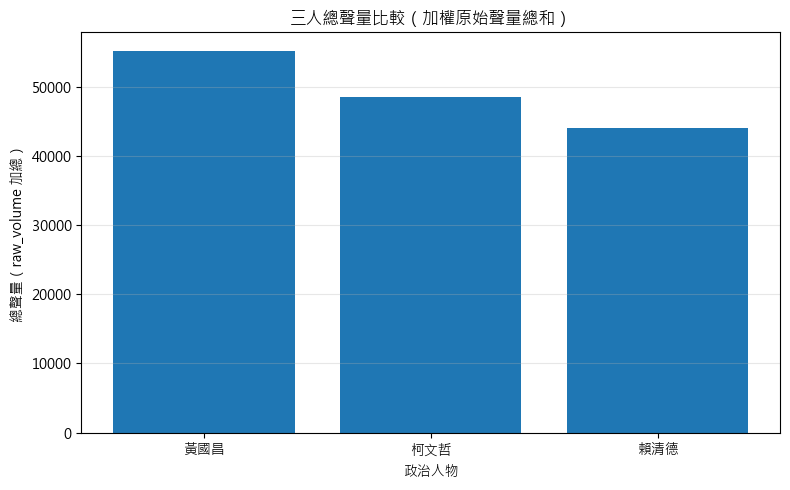

In [10]:
#三人總聲量比較（長條圖）
import matplotlib.pyplot as plt

# 排序一下方便視覺
pt = person_total.sort_values("total_raw_volume", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(pt["person"], pt["total_raw_volume"])
plt.title("三人總聲量比較（加權原始聲量總和）")
plt.xlabel("政治人物")
plt.ylabel("總聲量（raw_volume 加總）")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


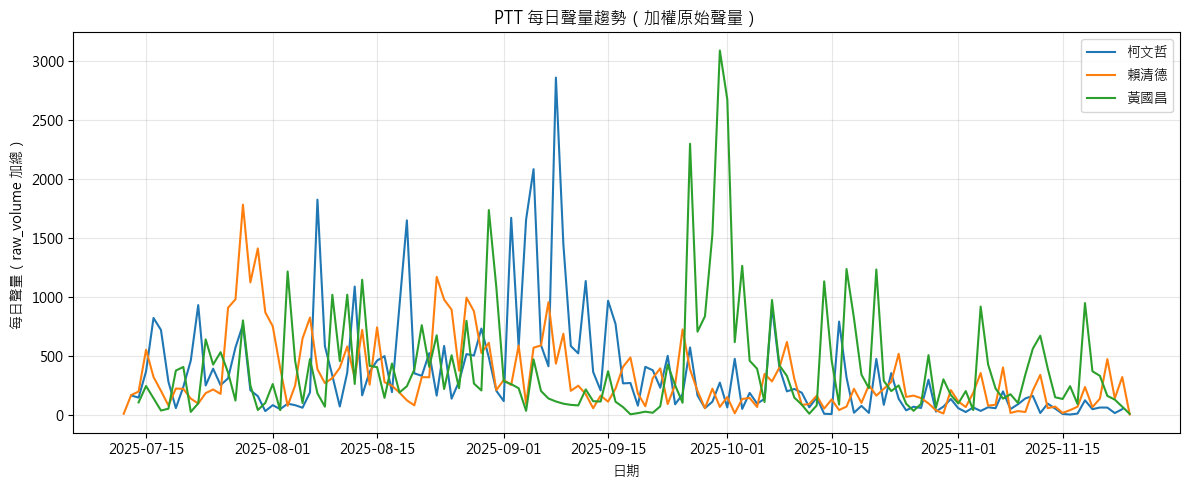

In [11]:
#每日聲量趨勢（折線）
import matplotlib.pyplot as plt
import pandas as pd

d = daily.copy()
d["date"] = pd.to_datetime(d["date"])

plt.figure(figsize=(12, 5))
for name, g in d.groupby("person"):
    g = g.sort_values("date")
    plt.plot(g["date"], g["daily_raw_volume"], label=name)

plt.title("PTT 每日聲量趨勢（加權原始聲量）")
plt.xlabel("日期")
plt.ylabel("每日聲量（raw_volume 加總）")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


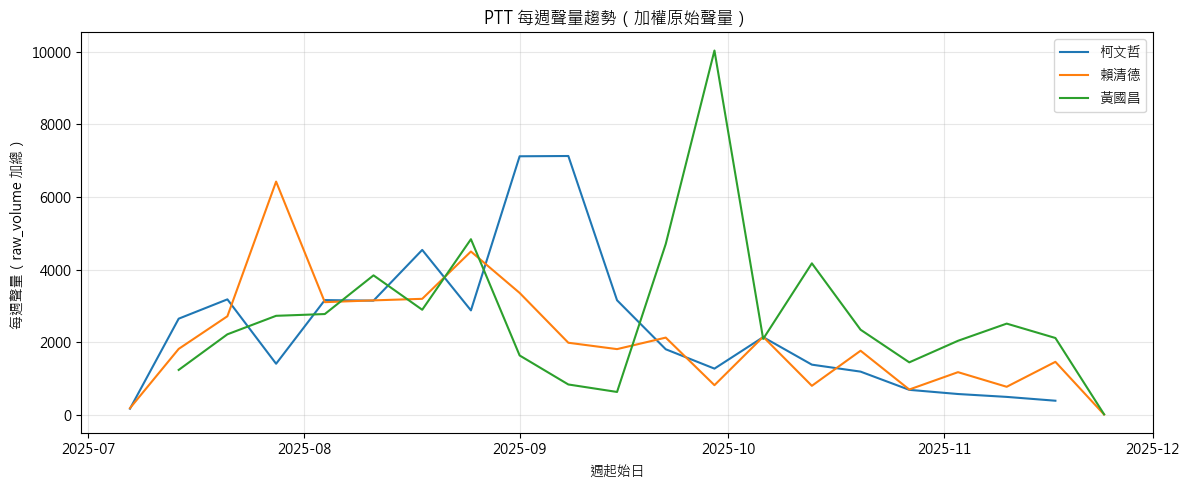

In [12]:
#每週聲量趨勢（折線）
import matplotlib.pyplot as plt
import pandas as pd

w = weekly.copy()
w["week_start"] = pd.to_datetime(w["week_start"])

plt.figure(figsize=(12, 5))
for name, g in w.groupby("person"):
    g = g.sort_values("week_start")
    plt.plot(g["week_start"], g["weekly_raw_volume"], label=name)

plt.title("PTT 每週聲量趨勢（加權原始聲量）")
plt.xlabel("週起始日")
plt.ylabel("每週聲量（raw_volume 加總）")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [13]:
#先算「整體每日聲量
import pandas as pd

# 確保有 date
if "date" not in combined.columns:
    combined["date"] = combined["時間"].dt.date

overall_daily = (
    combined.groupby("date")
    .agg(
        overall_posts=("person", "size"),
        overall_raw_volume=("raw_volume", "sum")
    )
    .reset_index()
    .sort_values("overall_raw_volume", ascending=False)
)

# Top 5 爆點日
overall_daily.head(5)


,date,overall_posts,overall_raw_volume
80,2025-09-30,139,3434.8
58,2025-09-08,240,3411.5
16,2025-07-28,138,3353.1
76,2025-09-26,125,3259.0
55,2025-09-05,201,3128.2


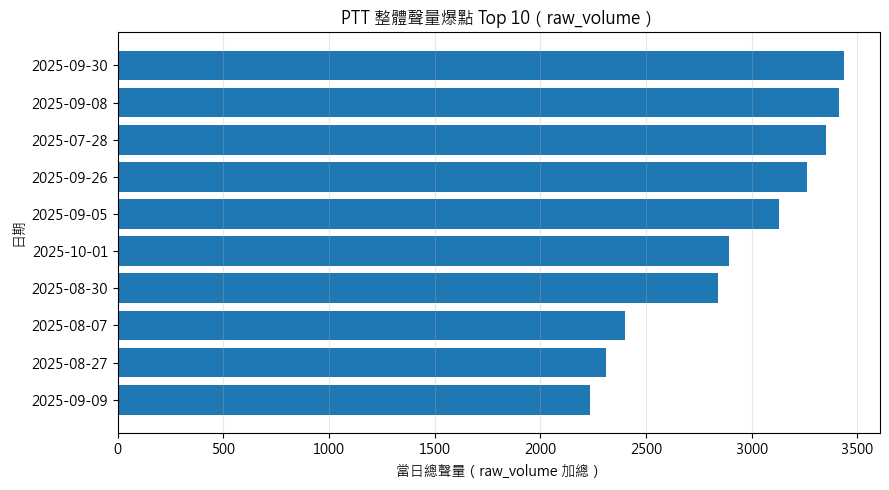

In [14]:
#畫出「整體爆點 Top 10」長條圖
top10 = overall_daily.head(10).sort_values("overall_raw_volume", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(top10["date"].astype(str), top10["overall_raw_volume"])
plt.title("PTT 整體聲量爆點 Top 10（raw_volume）")
plt.xlabel("當日總聲量（raw_volume 加總）")
plt.ylabel("日期")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()



In [15]:
#再加一個「爆點日三人貢獻拆解」
top_dates = overall_daily.head(5)["date"].tolist()

peak_by_person = (
    combined[combined["date"].isin(top_dates)]
    .groupby(["person", "date"])
    .agg(
        posts=("person", "size"),
        raw_volume=("raw_volume", "sum")
    )
    .reset_index()
    .sort_values(["date", "raw_volume"], ascending=[True, False])
)

peak_by_person


,person,date,posts,raw_volume
5,賴清德,2025-07-28,81,1783.7
10,黃國昌,2025-07-28,23,802.6
0,柯文哲,2025-07-28,34,766.8
1,柯文哲,2025-09-05,139,2084.3
6,賴清德,2025-09-05,25,571.5
11,黃國昌,2025-09-05,37,472.4
2,柯文哲,2025-09-08,185,2860.0
7,賴清德,2025-09-08,44,435.8
12,黃國昌,2025-09-08,11,115.7
13,黃國昌,2025-09-26,75,2299.5


In [16]:
#聲量占比 SOV（Share of Voice）

#先做「每人每日聲量」
daily = (
    combined.groupby(["person", "date"])
    .agg(
        daily_posts=("person", "size"),
        daily_raw_volume=("raw_volume", "sum")
    )
    .reset_index()
)


In [17]:
#算「當日三人合計聲量」
daily_total = (
    daily.groupby("date")["daily_raw_volume"]
    .sum()
    .reset_index(name="all_raw_volume")
)


In [18]:
#合併算 SOV
daily_sov = daily.merge(daily_total, on="date", how="left")
daily_sov["sov"] = daily_sov["daily_raw_volume"] / daily_sov["all_raw_volume"]

daily_sov.head()


,person,date,daily_posts,daily_raw_volume,all_raw_volume,sov
0,柯文哲,2025-07-13,11,166.7,336.3,0.495688
1,柯文哲,2025-07-14,8,148.6,456.7,0.325378
2,柯文哲,2025-07-15,15,370.5,1171.6,0.316234
3,柯文哲,2025-07-16,27,823.4,1146.7,0.718061
4,柯文哲,2025-07-17,39,721.8,966.6,0.746741


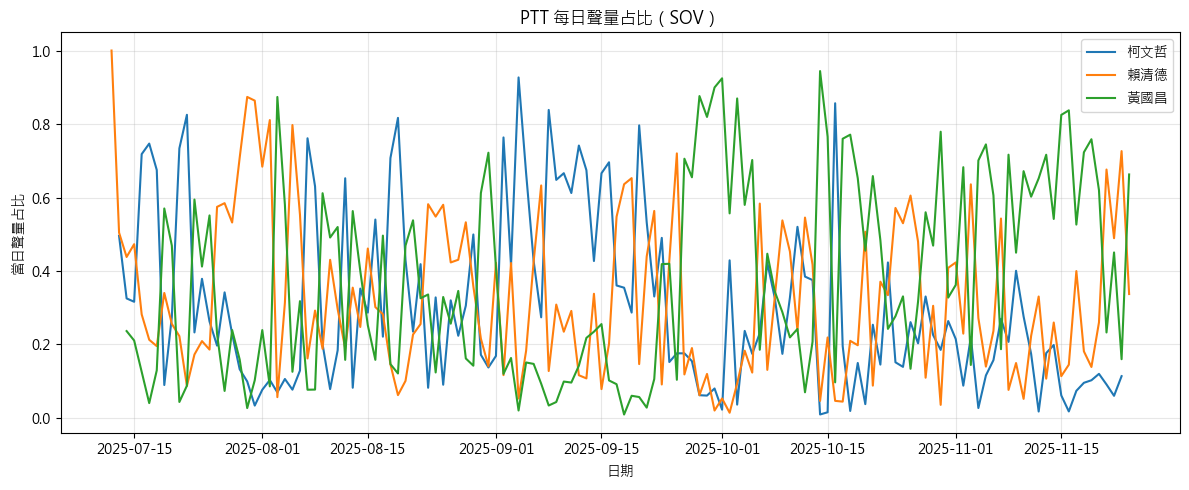

In [19]:
#畫「每日 SOV 趨勢折線」
daily_sov_plot = daily_sov.copy()
daily_sov_plot["date"] = pd.to_datetime(daily_sov_plot["date"])

plt.figure(figsize=(12, 5))
for name, g in daily_sov_plot.groupby("person"):
    g = g.sort_values("date")
    plt.plot(g["date"], g["sov"], label=name)

plt.title("PTT 每日聲量占比（SOV）")
plt.xlabel("日期")
plt.ylabel("當日聲量占比")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
!pip install wordcloud jieba -q


In [28]:
# ==============================
# 文字雲前處理（完整版）
# - 合併標題/內容/留言
# - 清除 PTT 留言的 推/噓/→ + ID
# - 設定中文字型
# - 合併停用詞（含你新增那包）
# - 文字雲函式（含可選濾純英文）
# ==============================

import pandas as pd
import re
import os
import jieba
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# ------------------------------
# 1) 清掉留言中的網友 ID
# ------------------------------
def clean_ptt_comments(text):
    if pd.isna(text):
        return ""
    
    lines = str(text).split("\n")
    cleaned_lines = []

    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        # 去掉「推/噓/→ + 帳號 + :」
        line = re.sub(r"^(推|噓|→)\s*[A-Za-z0-9_]+\s*:\s*", "", line)
        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)

# 建立乾淨留言欄位
if "留言" in combined.columns:
    combined["留言_clean"] = combined["留言"].apply(clean_ptt_comments)
else:
    combined["留言_clean"] = ""


# ------------------------------
# 2) 建立 all_text（標題 + 內容 + 乾淨留言）
# ------------------------------
text_cols = [c for c in ["標題", "內容"] if c in combined.columns]

combined["all_text"] = (
    combined[text_cols + ["留言_clean"]]
    .fillna("")
    .astype(str)
    .agg("\n".join, axis=1)
)


# ------------------------------
# 3) 找中文字型（Windows）
# ------------------------------
font_candidates = [
    r"C:\Windows\Fonts\msjh.ttc",   # 微軟正黑體
    r"C:\Windows\Fonts\msjhbd.ttc",
    r"C:\Windows\Fonts\simsun.ttc", # 新細明體（備用）
]

font_path = None
for f in font_candidates:
    if os.path.exists(f):
        font_path = f
        break

print("使用字型：", font_path)


# ------------------------------
# 4) 停用詞（你原本 + 你新增那包）
# ------------------------------
base_stopwords = set([
    "的","了","是","我","你","他","她","它","我們","你們","他們",
    "這個","那個","一個","沒有","有","不是","可以","就是",
    "https","http","推","噓","→"
])

extra_stopwords = set("""
的 是 在 我 他 她 你 了 和 也 就 都 被 很 及 但 不 於 之 啦 啊 喔 呢 吧
佛 佛教 釋迦牟尼佛 阿彌陀佛 藥師佛 菩薩 大乘 小乘 上座部
阿羅漢 辟支佛 獨覺佛 涅槃 佛陀 佛弟子 僧寶 佛法僧 三寶
喬達摩 悉達多 摩耶 薩都丹拿 瞿曇彌 那先尊者 馬哈希
經 經典 經書 法華經 心經 金剛經 華嚴經 般涅槃經 楞伽經
帝釋所問經 彌蘭王問經 支佛 聲聞 諸佛 十方 之言 眾生 釋迦 牟尼佛 佛是 獨覺 弟子 妙法 蓮華經
極樂 因為 這個 這樣 表示 真的 如果 可以 不是 什麼 還是 我們 就是 現在 這些 知道 是不是
所以 今天 實不應 如是 怎麼 還有 乃至 已經 但是 還有 彼是 結果 自己 一個 不要 應該
出世 解脫 大王 地藏王 作者 世界 所有 瞎掰 真正 成佛 覺者 一剎 大家 可能 不會 沒有
這種 繼續 只有 其他 例如 觀世音 他們 尊者 一切 菩薩觀 世音
柯文哲 黃國昌 賴清德 柯文 文哲 賴清 清德 黃國 國昌 黃 柯 賴 哲 文 清 德
的 是 在 我 他 她 你 了 和 也 就 都 被 很 及 但 不 於 之 啦 啊 喔 呢 吧 嗎 說 沒 跟 要 那 好 又 人 會 看 來 這
佛 佛教 釋迦牟尼佛 阿彌陀佛 藥師佛 菩薩 大乘 小乘 上座部
阿羅漢 辟支佛 獨覺佛 涅槃 佛陀 佛弟子 僧寶 佛法僧 三寶
喬達摩 悉達多 摩耶 薩都丹拿 瞿曇彌 那先尊者 馬哈希
經 經典 經書 法華經 心經 金剛經 華嚴經 般涅槃經 楞伽經
帝釋所問經 彌蘭王問經 支佛 聲聞 諸佛 十方 之言 眾生 釋迦 牟尼佛 佛是 獨覺 弟子 妙法 蓮華經
極樂 因為 這個 這樣 表示 真的 如果 可以 不是 什麼 還是 我們 就是 現在 這些 知道 是不是
所以 今天 實不應 如是 怎麼 還有 乃至 已經 但是 還有 彼是 結果 自己 一個 不要 應該
出世 解脫 大王 地藏王 作者 世界 所有 瞎掰 真正 成佛 覺者 一剎 大家 可能 不會 沒有
這種 繼續 只有 其他 繼續 例如 觀世音 他們 尊者 一切 菩薩觀 世音
""".split())

stopwords = base_stopwords | extra_stopwords
print("停用詞數量：", len(stopwords))


# ------------------------------
# 5) （可選）過濾純英文 token
# ------------------------------
def is_english_token(w):
    return re.fullmatch(r"[A-Za-z]+", w) is not None


# ------------------------------
# 6) 文字雲產生函式（完整）
# ------------------------------
def make_wordcloud_from_text(text, out_name=None, drop_english=True):
    # 斷詞 + 停用詞 + 可選去純英文
    tokens = []
    for w in jieba.lcut(str(text)):
        w = w.strip()
        if not w:
            continue
        if w in stopwords:
            continue
        if drop_english and is_english_token(w):
            continue
        tokens.append(w)

    wc_text = " ".join(tokens)

    wc = WordCloud(
        font_path=font_path,
        width=1200,
        height=800,
        background_color="white"
    ).generate(wc_text)

    plt.figure(figsize=(8, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    if out_name:
        wc.to_file(out_name)
        print("已存檔：", out_name)

print("✅ 文字雲前處理完成，可直接開始做文字雲")


使用字型： C:\Windows\Fonts\msjh.ttc
停用詞數量： 170
✅ 文字雲前處理完成，可直接開始做文字雲


=== 文字雲： 柯文哲 ===


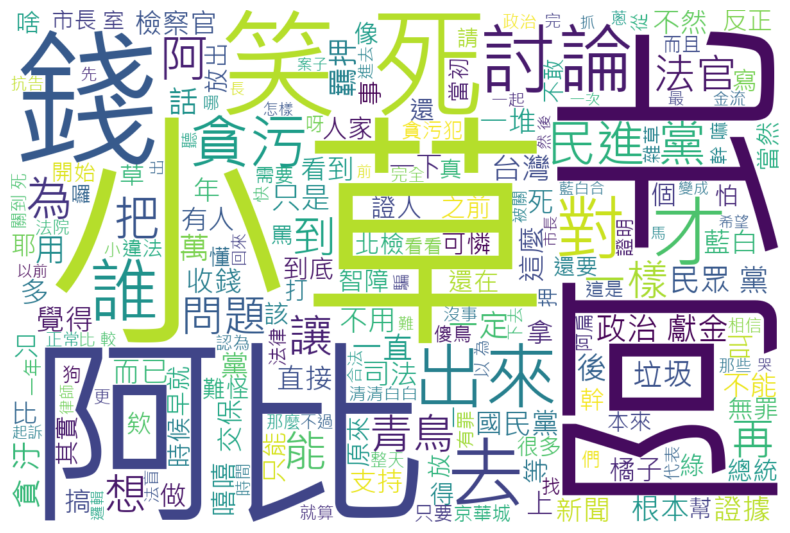

已存檔： wordcloud_柯文哲.png
=== 文字雲： 黃國昌 ===


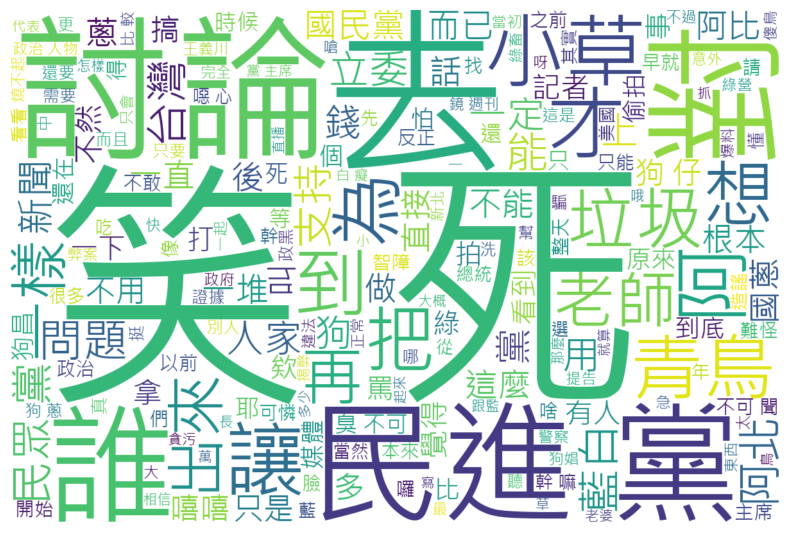

已存檔： wordcloud_黃國昌.png
=== 文字雲： 賴清德 ===


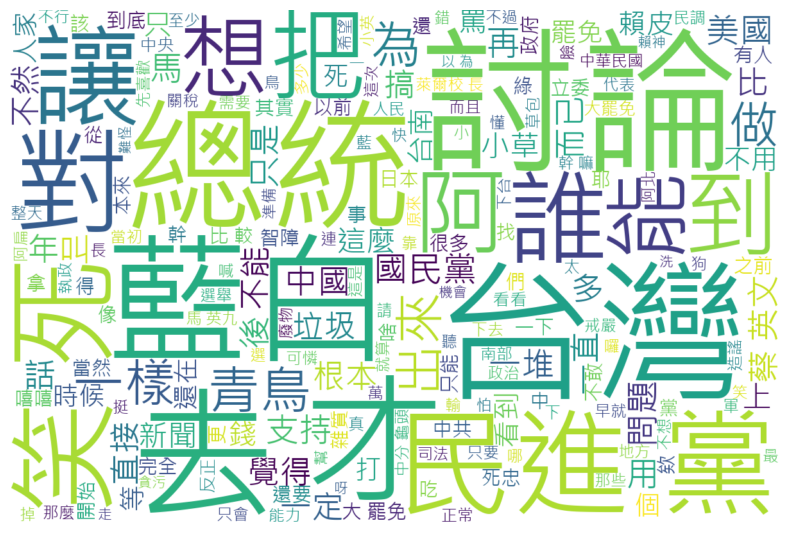

已存檔： wordcloud_賴清德.png


In [29]:
#三人各自文字雲
for p in combined["person"].unique():
    text = "\n".join(combined.loc[combined["person"] == p, "all_text"].tolist())
    print("=== 文字雲：", p, "===")
    make_wordcloud_from_text(text, out_name=f"wordcloud_{p}.png")


In [34]:
import pandas as pd
import numpy as np

combined["時間"] = pd.to_datetime(combined["時間"])
combined["date"] = combined["時間"].dt.date

# 1) 逐人總覽（文章層）
person_total = (
    combined.groupby("person")
    .agg(
        total_posts=("raw_volume", "size"),
        total_raw_volume=("raw_volume", "sum")
    )
    .reset_index()
)
person_total["avg_raw_per_post"] = person_total["total_raw_volume"] / person_total["total_posts"]

# 2) 每日聲量（人×日）
daily_raw = (
    combined.groupby(["person", "date"])["raw_volume"]
    .sum()
    .reset_index(name="daily_raw_volume")
)

# 3) 波動度（CV）
person_daily = (
    daily_raw.groupby("person")["daily_raw_volume"]
    .agg(daily_mean_raw="mean", daily_std_raw="std")
    .reset_index()
)
person_daily["daily_cv"] = person_daily["daily_std_raw"] / person_daily["daily_mean_raw"]

# 4) SOV 主導率
overall_daily = (
    daily_raw.groupby("date")["daily_raw_volume"]
    .sum()
    .reset_index(name="overall_raw_volume")
)

daily_sov = daily_raw.merge(overall_daily, on="date", how="left")
daily_sov["sov"] = daily_sov["daily_raw_volume"] / daily_sov["overall_raw_volume"]

max_sov = daily_sov.groupby("date")["sov"].max().reset_index(name="max_sov")
daily_sov = daily_sov.merge(max_sov, on="date", how="left")
daily_sov["is_dominant"] = daily_sov["sov"] == daily_sov["max_sov"]

total_days = daily_sov["date"].nunique()

sov_summary = (
    daily_sov.groupby("person")["is_dominant"]
    .sum()
    .reset_index(name="sov_dominance_days")
)
sov_summary["sov_dominance_rate"] = sov_summary["sov_dominance_days"] / total_days

# 5) 合併精華表
final_volume_core = (
    person_total
    .merge(person_daily[["person", "daily_cv"]], on="person", how="left")
    .merge(sov_summary[["person", "sov_dominance_rate"]], on="person", how="left")
)

# 只留精華欄位
final_volume_core = final_volume_core[[
    "person",
    "total_posts",
    "total_raw_volume",
    "avg_raw_per_post",
    "daily_cv",
    "sov_dominance_rate"
]].sort_values("total_raw_volume", ascending=False).reset_index(drop=True)

final_volume_core


,person,total_posts,total_raw_volume,avg_raw_per_post,daily_cv,sov_dominance_rate
0,黃國昌,2789,55071.3,19.745895,1.191543,0.419118
1,柯文哲,2675,48430.5,18.104860,1.246870,0.235294
2,賴清德,2961,43969.7,14.849612,0.953939,0.345588


爆點 Top 3 日期： [datetime.date(2025, 9, 30), datetime.date(2025, 9, 8), datetime.date(2025, 7, 28)]
=== 爆點日文字雲（Top 3 days）===


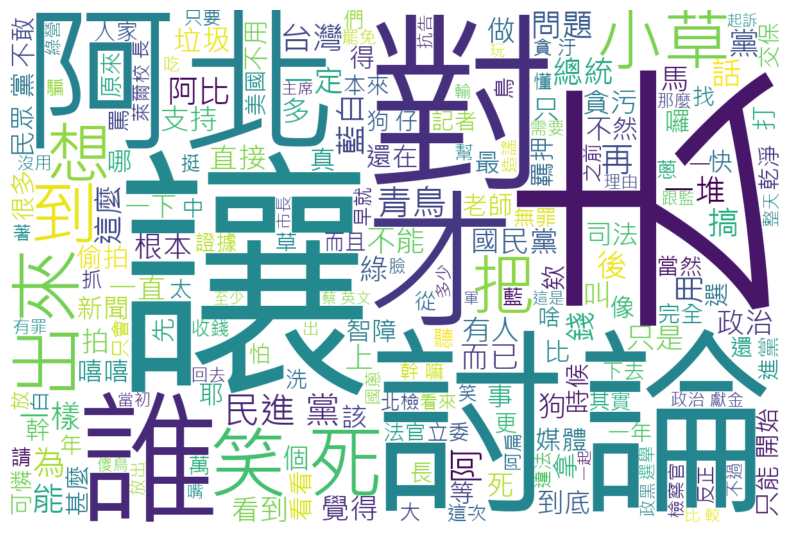

已存檔： wordcloud_peak_top3days.png


In [30]:
#爆點 Top 3 日期文字雲
import pandas as pd

# 確保有 date
if "date" not in combined.columns:
    combined["date"] = combined["時間"].dt.date

# 先算整體每日 raw_volume
overall_daily = (
    combined.groupby("date")
    .agg(overall_raw_volume=("raw_volume", "sum"))
    .reset_index()
    .sort_values("overall_raw_volume", ascending=False)
)

# 取 Top 3 爆點日
top_dates = overall_daily.head(3)["date"].tolist()
print("爆點 Top 3 日期：", top_dates)

# 合併這三天的文字
peak_df = combined[combined["date"].isin(top_dates)]
peak_text = "\n".join(peak_df["all_text"].tolist())

print("=== 爆點日文字雲（Top 3 days）===")
make_wordcloud_from_text(peak_text, out_name="wordcloud_peak_top3days.png")


=== 爆點日文字雲：2025-09-30 ===


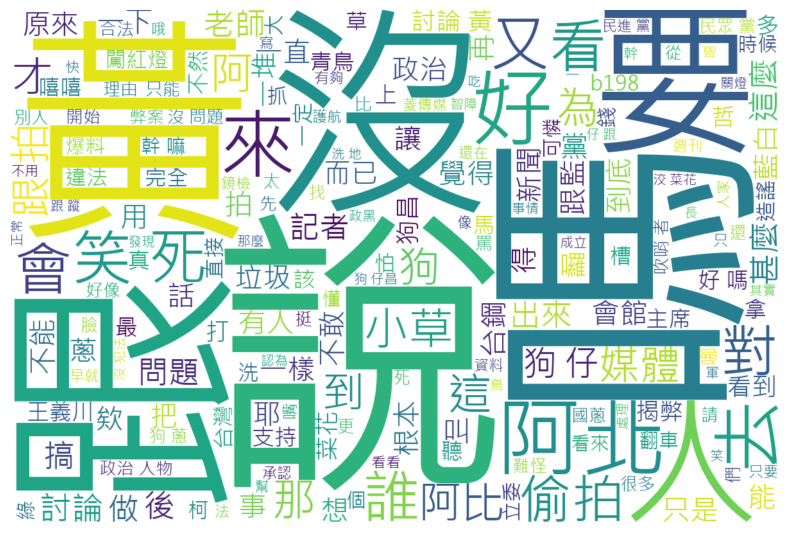

已存檔： wordcloud_peak_2025-09-30.png
=== 爆點日文字雲：2025-09-08 ===


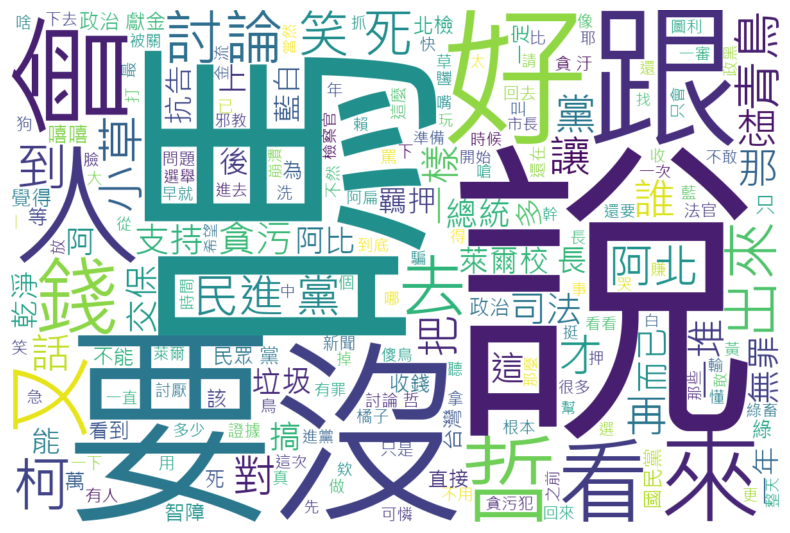

已存檔： wordcloud_peak_2025-09-08.png
=== 爆點日文字雲：2025-07-28 ===


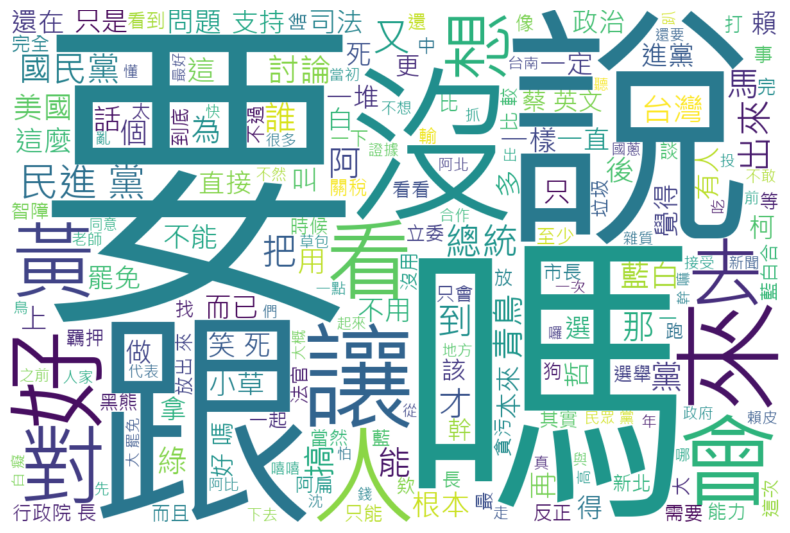

已存檔： wordcloud_peak_2025-07-28.png


In [31]:
#每個爆點日各做一張
for d in top_dates:
    day_df = combined[combined["date"] == d]
    day_text = "\n".join(day_df["all_text"].tolist())
    print(f"=== 爆點日文字雲：{d} ===")
    make_wordcloud_from_text(day_text, out_name=f"wordcloud_peak_{d}.png")
